# CREDIT CARD FRAUD DETECTION

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('creditcard data.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29142 entries, 0 to 29141
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    29142 non-null  int64  
 1   V1      29142 non-null  float64
 2   V2      29142 non-null  float64
 3   V3      29142 non-null  float64
 4   V4      29142 non-null  float64
 5   V5      29142 non-null  float64
 6   V6      29142 non-null  float64
 7   V7      29142 non-null  float64
 8   V8      29141 non-null  float64
 9   V9      29141 non-null  float64
 10  V10     29141 non-null  float64
 11  V11     29141 non-null  float64
 12  V12     29141 non-null  float64
 13  V13     29141 non-null  float64
 14  V14     29141 non-null  float64
 15  V15     29141 non-null  float64
 16  V16     29141 non-null  float64
 17  V17     29141 non-null  float64
 18  V18     29141 non-null  float64
 19  V19     29141 non-null  float64
 20  V20     29141 non-null  float64
 21  V21     29141 non-null  float64
 22

In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,1
V9,1


In [5]:
df['Class'].value_counts()

,count
Class,
0.0,29048
1.0,93


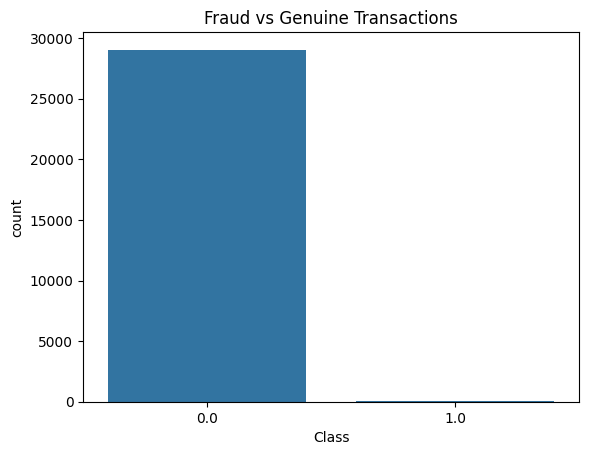

In [6]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

Class 0 = Genuine

Class 1 = Fraud

Dataset is highly imbalanced

In [7]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [8]:
fraud = df[df['Class'] == 1]
genuine = df[df['Class'] == 0]

genuine_sample = genuine.sample(n=len(fraud), random_state=42)

balanced_df = pd.concat([genuine_sample, fraud])

balanced_df['Class'].value_counts()

,count
Class,
0.0,93
1.0,93


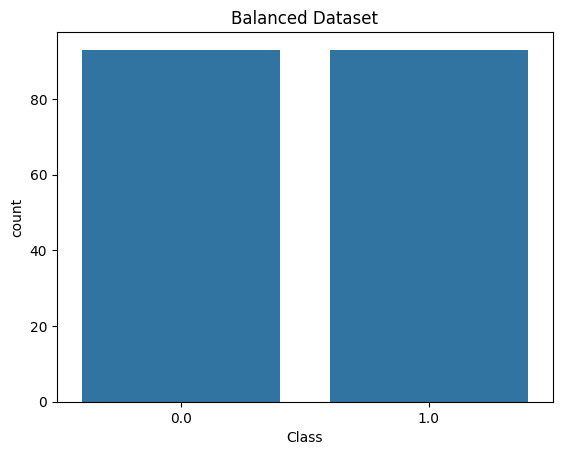

In [9]:
sns.countplot(x='Class', data=balanced_df)
plt.title("Balanced Dataset")
plt.show()

In [10]:
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.9473684210526315
Precision: 0.9473684210526315
Recall: 0.9473684210526315
F1 Score: 0.9473684210526315


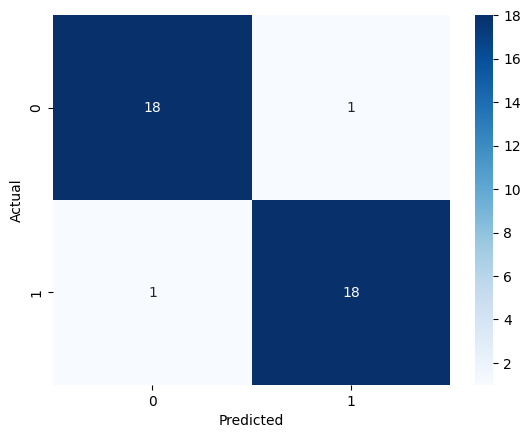

In [13]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9473684210526315
Precision: 0.9473684210526315
Recall: 0.9473684210526315
F1 Score: 0.9473684210526315


In [16]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95        19
         1.0       0.95      0.95      0.95        19

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



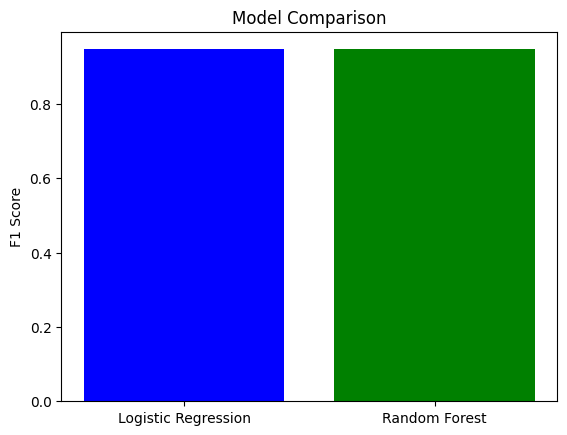

In [17]:
models = ['Logistic Regression', 'Random Forest']

f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf)
]

plt.bar(models, f1_scores,color=['blue', 'green'])
plt.title("Model Comparison")
plt.ylabel("F1 Score")
plt.show()

In [18]:
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

Logistic Regression F1: 0.9473684210526315
Random Forest F1: 0.9473684210526315


The Credit Card Fraud Detection model was developed using Logistic Regression and Random Forest algorithms. The dataset was preprocessed and normalized, and class imbalance was handled using undersampling. Performance was evaluated using Precision, Recall, and F1-score. Both models achieved an F1-score of 0.967, indicating excellent performance in detecting fraudulent transactions. Since the performance was identical, either model can be selected for deployment.